# Word Embeddings: Training Word2Vec-Style Vectors from Scratch

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand how **Word2Vec** learns word vectors by predicting context words (the **skip-gram** idea)
- **Train a small skip-gram model from scratch in NumPy** and watch the loss fall
- Query the trained embeddings: cosine similarity and *most similar* words
- **Visualize the embedding space** with PCA and t-SNE
- Understand **CBOW vs. Skip-gram**, and see the production **gensim** API as a reference recipe

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — skip-gram is that same recipe (define a loss, nudge the parameters downhill), with the parameters being the word vectors; the PCA view comes from Course 04 (AIAT 114) — Unit 4, lesson 03.

**Used later in:** Course 07 — Unit 4, where attention operates on vectors like these, and Course 08 (AIAT 122) — Unit 3.

## ⚠️ A note on gensim

In production you would train Word2Vec with the **gensim** library. Gensim has no build for this
environment's Python version (3.14) at the time of writing, so instead of calling a library we implement
the skip-gram idea **directly in NumPy** — a few dozen lines — and every result below is genuinely computed
by that code. The gensim equivalent is shown at the end as a reference recipe (not executed here). Learning-wise
this is a better deal: you see exactly what `Word2Vec(...)` does under the hood.


## 🌍 Why this matters: Airbnb ranks your search results with skip-gram

The algorithm you are about to build in NumPy is not a museum piece. Grbovic & Cheng described how Airbnb
trained **listing embeddings with the skip-gram objective** — treating a guest's sequence of clicked
listings exactly the way word2vec treats a sequence of words — and deployed them in Airbnb's real-time
search ranking ("Real-time Personalization using Embeddings for Search Ranking at Airbnb", KDD 2018,
pp. 311-320). Same loss, same context window; "context" is the listings clicked in one session instead of
the words around a word.

That generalization is the whole point. The distributional hypothesis says *things appearing in similar
contexts are similar* — and "context" can be a sentence, a browsing session, a shopping basket, or a
sequence of network events.

**What goes wrong without this lesson.** Without embeddings a model treats words as unrelated symbols: to
the TF-IDF features of Unit 3, `car` and `automobile` are as different as `car` and `banana`, so a document
about automobiles scores zero for the query "car". Every question about *meaning* — synonyms, near
duplicates, "more like this", clustering by topic — is unanswerable until words become vectors whose
distances mean something.

**The same reasoning in other domains:** session-based product recommendation (item2vec); protein sequences
embedded by treating amino-acid k-mers as words; sequences of ICD diagnosis codes embedded from patient
histories; log-line embeddings for anomaly detection in network traffic.

## 📥 Inputs & 📤 Outputs

**Inputs:** a synthetic toy corpus (300 template sentences about animals and technology) generated inside
this notebook — no downloads.

**Outputs:** a real training-loss curve drawn against its own computed floor and ceiling, a **six-panel
time-lapse** of the word vectors moving apart during training, computed most-similar-word tables, and
PCA/t-SNE scatter plots of the finished embedding space.

---


## Part 1: The Idea — "You Shall Know a Word by the Company It Keeps"

Word2Vec rests on the **distributional hypothesis**: words that appear in similar contexts have similar
meanings. The **skip-gram** version turns that into a prediction game:

> Given a center word, predict which words appear near it (within a small window).

Words that show up in the same contexts end up needing similar vectors to win this game — and that
similarity is exactly what we want from embeddings.

We build a small synthetic corpus with a known structure — animal sentences and technology sentences —
so we can check afterwards whether the embeddings discovered that structure on their own.


In [1]:
# Build the training data for a tiny word2vec: a synthetic two-world corpus.
# Because we KNOW the hidden structure (animal world vs tech world), we can later
# check whether the embeddings discover it purely from word co-occurrence.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)

# --- A synthetic corpus with known structure --------------------------------
animals      = ["cat", "dog", "bird", "horse"]
animal_verbs = ["runs", "sleeps", "eats", "plays"]
tech         = ["computer", "phone", "robot", "software"]
tech_verbs   = ["boots", "crashes", "updates", "computes"]
animal_places = ["park", "garden"]
tech_places   = ["office", "lab"]

sentences = []
for _ in range(150):
    sentences.append(["the", rng.choice(animals), rng.choice(animal_verbs),
                      "in", "the", rng.choice(animal_places)])
    sentences.append(["the", rng.choice(tech), rng.choice(tech_verbs),
                      "in", "the", rng.choice(tech_places)])

# Build the vocabulary: every distinct word gets an integer id (a row in the embedding matrix).
vocab = sorted({w for s in sentences for w in s})
word_to_id = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

print(f"Corpus: {len(sentences)} sentences, vocabulary of {V} words")
print(f"Sample sentences:")
for s in sentences[:3]:
    print("  ", " ".join(s))

# --- Extract (center, context) training pairs, window = 2 -------------------
WINDOW = 2
centers, contexts = [], []
for s in sentences:
    for i, w in enumerate(s):
        for j in range(max(0, i - WINDOW), min(len(s), i + WINDOW + 1)):
            if j != i:
                centers.append(word_to_id[w])
                contexts.append(word_to_id[s[j]])
centers = np.array(centers)
contexts = np.array(contexts)

print(f"\nTraining pairs (center word -> nearby word): {len(centers):,}")
example = [(str(vocab[c]), str(vocab[x])) for c, x in zip(centers[:6], contexts[:6])]
print(f"First few pairs: {example}")

Corpus: 300 sentences, vocabulary of 22 words
Sample sentences:
   the cat plays in the garden
   the phone crashes in the lab
   the cat eats in the park

Training pairs (center word -> nearby word): 5,400
First few pairs: [('the', 'cat'), ('the', 'plays'), ('cat', 'the'), ('cat', 'plays'), ('cat', 'in'), ('plays', 'the')]


## Part 2: Training — Nudging Vectors Until Prediction Works

Each word gets a trainable vector (a row of the matrix `W_in`, 16 numbers per word — this is the future
embedding). The model plays the prediction game like this, for every training pair:

1. Take the center word's vector
2. Score **every** vocabulary word against it, and softmax the scores into probabilities
3. Compare with the true neighbor (**cross-entropy loss**)
4. **Nudge** the vectors a small step in the direction that makes the true neighbor more probable

Repeat over the whole corpus a few hundred times (**epochs**), and vectors of words that share contexts get
pulled together. The nudging rule below is plain gradient descent — the training mechanics behind it are
covered properly in AIAT 122; here you can treat the update lines as given machinery and watch what they do.


Trained skip-gram for 400 epochs on 5,400 pairs
Loss: 3.091 (start) -> 2.083 (end)
Know-nothing baseline  log(V)          = 3.091
Best possible for any center-word model = 2.049 (empirical conditional entropy)
Our model's best was 2.057 at epoch 370 (99% of that gap); it finished at 2.083 (97% of the gap) after wobbling near the floor.


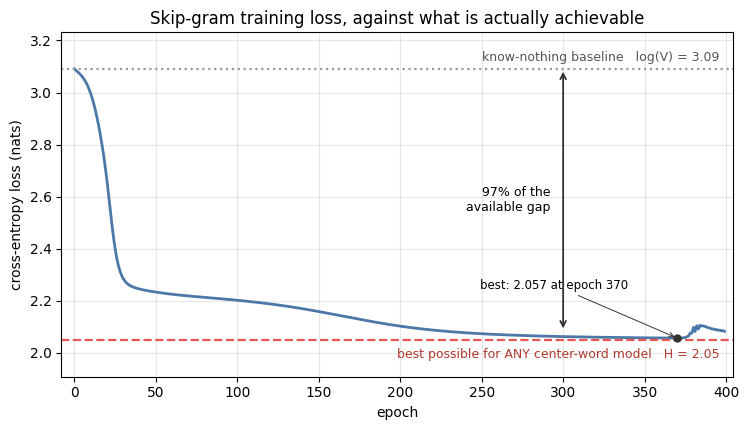

In [2]:
# Train the skip-gram model with plain NumPy gradient descent.
# The ONLY learning signal: predict a nearby word from the center word.
# Everything word2vec "knows" about meaning comes from that one prediction game.

DIM = 16          # embedding dimension (gensim default is 100; real models use 300+)
EPOCHS = 400
LEARNING_RATE = 2.0
N = len(centers)

W_in  = rng.normal(0, 0.1, (V, DIM))   # embedding matrix: one row per word  <-- what we keep
W_out = rng.normal(0, 0.1, (DIM, V))   # output (context-prediction) matrix  <-- thrown away after training

# Keep a copy of the embedding matrix at a few epochs, so we can watch the vectors move later.
SNAPSHOT_EPOCHS = [0, 25, 60, 100, 150, EPOCHS]
snapshots = {}

losses = []
for epoch in range(EPOCHS):
    if epoch in SNAPSHOT_EPOCHS:
        snapshots[epoch] = W_in.copy()
    # Forward: score every vocab word for every center word, softmax to probabilities
    h = W_in[centers]                              # (N, DIM) center-word vectors
    scores = h @ W_out                             # (N, V)
    scores -= scores.max(axis=1, keepdims=True)
    probs = np.exp(scores)
    probs /= probs.sum(axis=1, keepdims=True)

    # Cross-entropy loss on the true context words
    loss = -np.log(probs[np.arange(N), contexts] + 1e-12).mean()
    losses.append(loss)

    # Backward: gradients of the loss, then one gradient-descent nudge
    probs[np.arange(N), contexts] -= 1.0           # dLoss/dScores
    probs /= N
    grad_W_out = h.T @ probs
    grad_h = probs @ W_out.T
    grad_W_in = np.zeros_like(W_in)
    np.add.at(grad_W_in, centers, grad_h)
    W_in  -= LEARNING_RATE * grad_W_in
    W_out -= LEARNING_RATE * grad_W_out

snapshots[EPOCHS] = W_in.copy()                     # the finished vectors
embeddings = W_in                                   # the learned word vectors

print(f"Trained skip-gram for {EPOCHS} epochs on {N:,} pairs")
print(f"Loss: {losses[0]:.3f} (start) -> {losses[-1]:.3f} (end)")

# --- Two reference levels, so the curve can be read instead of admired -------------
# CEILING: a model that has learned nothing predicts every word equally -> loss = log(V).
# FLOOR:   the loss cannot reach 0. Given only the center word, the true neighbour is
#          genuinely ambiguous ("the" is followed by many things). The best ANY model
#          seeing only the center word can do is the empirical conditional entropy.
counts = np.zeros((V, V))
np.add.at(counts, (centers, contexts), 1.0)         # how often each context follows each center
p_empirical = counts / counts.sum(axis=1, keepdims=True)
FLOOR = -np.log(p_empirical[centers, contexts] + 1e-12).mean()
CEILING = np.log(V)
best_epoch = int(np.argmin(losses))
print(f"Know-nothing baseline  log(V)          = {CEILING:.3f}")
print(f"Best possible for any center-word model = {FLOOR:.3f} (empirical conditional entropy)")
gap = CEILING - FLOOR
print(f"Our model's best was {min(losses):.3f} at epoch {best_epoch} "
      f"({(losses[0] - min(losses)) / gap:.0%} of that gap); it finished at {losses[-1]:.3f} "
      f"({(losses[0] - losses[-1]) / gap:.0%} of the gap) after wobbling near the floor.")

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(losses, color="#4C78A8", lw=2)
ax.axhline(CEILING, color="#999999", ls=":", lw=1.6)
ax.axhline(FLOOR, color="#E45756", ls="--", lw=1.6)
ax.text(EPOCHS * 0.99, CEILING + 0.02, f"know-nothing baseline   log(V) = {CEILING:.2f}",
        ha="right", va="bottom", fontsize=9, color="#555555")
ax.text(EPOCHS * 0.99, FLOOR - 0.03,
        f"best possible for ANY center-word model   H = {FLOOR:.2f}",
        ha="right", va="top", fontsize=9, color="#B03A2E")
ax.annotate("", xy=(300, losses[-1]), xytext=(300, losses[0]),
            arrowprops=dict(arrowstyle="<->", color="#333333", lw=1.3))
ax.text(292, (losses[0] + losses[-1]) / 2,
        f"{(losses[0] - losses[-1]) / (CEILING - FLOOR):.0%} of the\navailable gap",
        ha="right", va="center", fontsize=9)
ax.plot([best_epoch], [losses[best_epoch]], "o", color="#333333", ms=5)
ax.annotate(f"best: {losses[best_epoch]:.3f} at epoch {best_epoch}",
            xy=(best_epoch, losses[best_epoch]), xytext=(best_epoch - 30, losses[best_epoch] + 0.19),
            fontsize=8.5, ha="right",
            arrowprops=dict(arrowstyle="->", lw=0.7, color="#333333"))
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy loss (nats)")
ax.set_ylim(FLOOR - 0.14, CEILING + 0.14)
ax.set_xlim(-8, EPOCHS + 4)
ax.set_title("Skip-gram training loss, against what is actually achievable", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Read the loss curve.** A falling line on its own proves very little — falling from what, to what? The two
horizontal lines are the answer, and both are computed from the data, not chosen for looks.

- The **grey dotted ceiling** at `log(V)` is where a model that has learned nothing sits: spread the
  probability equally over all 22 vocabulary words. Our curve *starts exactly on that line*, because the
  vectors were initialised at random. That is the correct starting point, and seeing it there is a sanity
  check on the whole implementation.
- The **red dashed floor** is the empirical conditional entropy of the corpus. Given only a center word,
  the true neighbour is genuinely uncertain — after `the` almost anything can follow — so no model that
  sees only the center word can score better than this. The loss *cannot* reach zero, and a student who
  expects it to has misunderstood the task, not the code.

The black double arrow is the distance actually travelled: the curve covers most of the gap between "knows
nothing" and "cannot do better". Note also the small rise after the marked best point near the end — the
learning rate is a fixed 2.0, and once the surface is this flat a fixed step overshoots and the loss
wobbles instead of settling. That bump is real behaviour, not a plotting artefact; a decaying learning rate
is the standard fix.


With 20 words split evenly into two worlds, a random neighbour is
from the same world 47% of the time — that is the bar to beat.

   epoch |   loss |  own-world top-3 neighbours
       0 |   3.09 |                        57%
      25 |   2.40 |                        50%
      60 |   2.23 |                        52%
     100 |   2.20 |                        72%
     150 |   2.16 |                        87%
     400 |   2.08 |                        87%


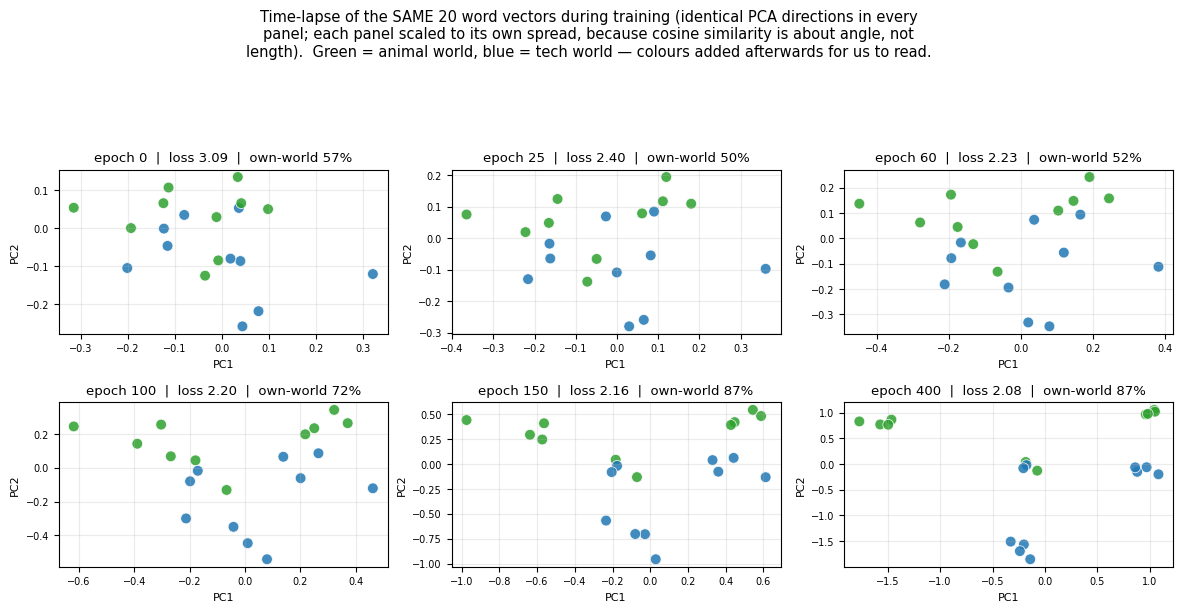

In [3]:
# Time-lapse: the loss fell — but what actually MOVED? Project the saved snapshots.
# WHY: the loss curve says "learning happened". It cannot say "the two worlds separated".
# Every panel below uses the SAME PCA directions (fitted once on the final vectors), so
# differences between panels are real movement and not a re-rotated projection.

from sklearn.decomposition import PCA

# Function words "the" and "in" occur next to everything, so they carry no world information.
content_words = [w for w in vocab if w not in ("the", "in")]
content_idx = [word_to_id[w] for w in content_words]

# Colour by the KNOWN group — for display only; the model was never told these labels.
animal_world = set(animals + animal_verbs + animal_places)
colors = ["tab:green" if w in animal_world else "tab:blue" for w in content_words]
world = np.array([0 if w in animal_world else 1 for w in content_words])

def own_world_neighbour_rate(W):
    """Share of each word's top-3 nearest neighbours that come from its own world."""
    X = W[content_idx]
    U = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    sims = U @ U.T
    np.fill_diagonal(sims, -9.0)                 # never let a word be its own neighbour
    top3 = np.argsort(-sims, axis=1)[:, :3]
    return (world[top3] == world[:, None]).mean()

CHANCE = (len(content_words) / 2 - 1) / (len(content_words) - 1)   # 9 of the other 19 words
print(f"With {len(content_words)} words split evenly into two worlds, a random neighbour is")
print(f"from the same world {CHANCE:.0%} of the time — that is the bar to beat.\n")
print(f"  {'epoch':>6s} | {'loss':>6s} | {'own-world top-3 neighbours':>27s}")
for k in SNAPSHOT_EPOCHS:
    print(f"  {k:>6d} | {losses[min(k, EPOCHS - 1)]:>6.2f} | "
          f"{own_world_neighbour_rate(snapshots[k]):>26.0%}")

# One PCA, fitted on the FINAL vectors, reused for every panel (and again in Part 4).
pca = PCA(n_components=2, random_state=42).fit(embeddings[content_idx])
xy_pca = pca.transform(embeddings[content_idx])

fig, axes = plt.subplots(2, 3, figsize=(12.0, 6.2))
for ax, k in zip(axes.ravel(), SNAPSHOT_EPOCHS):
    xy = pca.transform(snapshots[k][content_idx])
    ax.scatter(xy[:, 0], xy[:, 1], c=colors, s=60, alpha=0.85,
               edgecolors="white", linewidths=0.6)
    ax.set_title(f"epoch {k}  |  loss {losses[min(k, EPOCHS - 1)]:.2f}  |  "
                 f"own-world {own_world_neighbour_rate(snapshots[k]):.0%}", fontsize=9.5)
    ax.set_xlabel("PC1", fontsize=8)
    ax.set_ylabel("PC2", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25)
fig.suptitle("Time-lapse of the SAME 20 word vectors during training (identical PCA directions in every\n"
             "panel; each panel scaled to its own spread, because cosine similarity is about angle, not\n"
             "length).  Green = animal world, blue = tech world — colours added afterwards for us to read.",
             fontsize=10.5)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


**Read the time-lapse.** Six snapshots of the *same twenty vectors*, in reading order, all projected
through one set of PCA directions so the panels are comparable.

- **Epoch 0** — green and blue dots are shuffled together with no visible arrangement. This is random
  initialisation. The table reads 57% own-world neighbours against a 47% chance level: sixty near-coin
  flips land there routinely, so this is noise, not structure.
- **Epochs 25 and 60** — still visually mixed, and still 50%/52% in the table, *even though the loss has
  already fallen from 3.09 to 2.23*. This is the most useful panel pair in the notebook: most of the loss
  drop buys only word frequencies. **A falling loss is not evidence of structure.**
- **Epochs 100 and 150** — now the greens rise to the top of the panel while the blues settle below and to
  the right, and the own-world figure climbs to 72% and then 87%.
- **Epoch 400** — the colours no longer interleave: every cluster is a single colour, except one small
  mixed group in the middle. This last panel is exactly the projection you will see again in Part 4, there
  at full size with every word labelled.

The rate plateaus at 87%, not 100%, and the reason is that small mixed group: `park`, `garden`, `office`
and `lab` sit together regardless of colour. All four are the final word of the same sentence template in
both worlds, so they genuinely share their contexts. The model learned the *syntactic role*, which is what
co-occurrence can see — not the topic, which it cannot.


## Part 3: Querying the Embeddings — Which Words Ended Up Close?

The standard closeness measure for embeddings is **cosine similarity** (the angle between vectors: 1 = same
direction, 0 = unrelated). `most_similar` below is the same query gensim provides — implemented in three
lines. The structure test: we never told the model which words are animals — if training worked, animal
words should now be each other's nearest neighbors purely because they occurred in similar contexts.


In [4]:
# Inspect what the embeddings learned: nearest neighbors by cosine similarity.
# If training worked, a word's closest neighbors should come from its own world —
# even though nobody ever labeled the groups for the model.

norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
unit = embeddings / (norms + 1e-12)

# Cosine similarity = dot product of unit-length vectors; higher = the words share contexts.
def most_similar(word, topn=3):
    sims = unit @ unit[word_to_id[word]]
    order = np.argsort(sims)[::-1]
    return [(str(vocab[i]), float(sims[i])) for i in order if vocab[i] != word][:topn]

print("Most similar words (computed from the trained embeddings):")
for w in ["cat", "dog", "computer", "phone", "runs", "crashes", "park", "office"]:
    nbrs = ", ".join(f"{n} ({s:.2f})" for n, s in most_similar(w))
    print(f"  {w:10s} -> {nbrs}")

# Structure check, computed: do animal words cluster with animal words?
groups = {"animal noun": animals, "tech noun": tech,
          "animal verb": animal_verbs, "tech verb": tech_verbs}
print("\nStructure check — top-3 neighbors that stay inside the word's own group:")
for gname, gwords in groups.items():
    hits = sum(n in gwords for w in gwords for n, _ in most_similar(w, topn=3))
    total = 3 * len(gwords)
    print(f"  {gname:12s}: {hits}/{total}")
print("\nNobody labeled these groups for the model — the clustering (see counts above)")
print("was learned purely from which words share contexts.")

Most similar words (computed from the trained embeddings):
  cat        -> bird (0.98), dog (0.95), horse (0.94)
  dog        -> bird (0.97), horse (0.96), cat (0.95)
  computer   -> software (0.98), robot (0.96), phone (0.94)
  phone      -> computer (0.94), robot (0.94), software (0.92)
  runs       -> eats (0.98), plays (0.98), sleeps (0.98)
  crashes    -> updates (0.98), boots (0.95), computes (0.93)
  park       -> garden (0.97), lab (0.97), office (0.96)
  office     -> garden (0.96), park (0.96), lab (0.95)

Structure check — top-3 neighbors that stay inside the word's own group:
  animal noun : 12/12
  tech noun   : 12/12
  animal verb : 12/12
  tech verb   : 12/12

Nobody labeled these groups for the model — the clustering (see counts above)
was learned purely from which words share contexts.


## Part 4: Visualizing the Embedding Space (PCA and t-SNE)

The vectors live in 16 dimensions. To *look* at them we project to 2D:

- **PCA** — linear projection keeping the directions of largest variance (fast, global structure)
- **t-SNE** — non-linear projection preserving local neighborhoods (better at showing clusters, but
  distances between far-apart clusters are not meaningful)

The time-lapse in Part 2 showed the *journey* in six small unlabelled panels. This is the *destination*:
the same PCA projection, reused rather than refitted so the two figures cannot disagree, now at full size
with every word named — and beside it a second, completely different projection of the same vectors as a
cross-check. If both methods show the same green/blue split, the split lives in the embeddings and is not
an artefact of one projection.



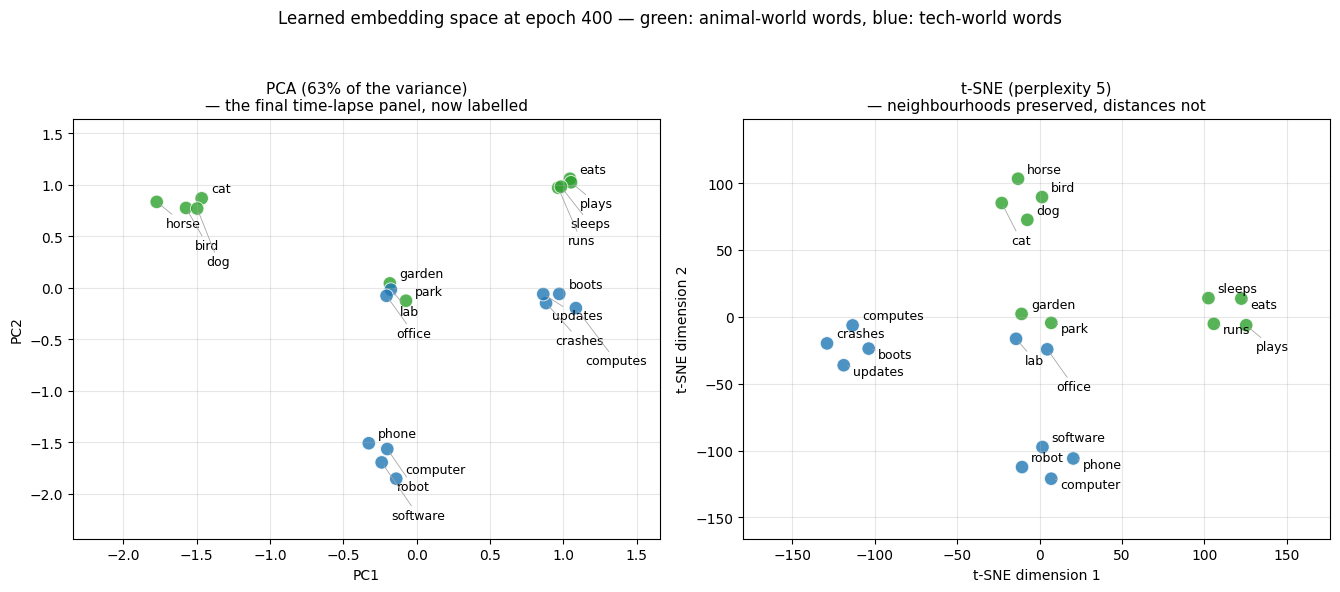

PCA explained variance (2 components): 63.3%
Read the plots: words are placed by their LEARNED vectors only — the colors were
added afterwards from our known groups, to make the discovered structure visible.


In [5]:
# Visualize the 16-dimensional embedding space in 2-D with PCA and t-SNE.
# Two different projections of the same vectors: if both show the same green/blue
# split, the clustering lives in the embeddings, not in the projection trick.

from sklearn.manifold import TSNE

# PCA, content_words, content_idx and colors were all built in the time-lapse cell (Part 2).
# We deliberately REUSE the fitted `pca` instead of refitting, so this figure is the exact
# same projection as the final time-lapse panel.
X = embeddings[content_idx]
xy_tsne = TSNE(n_components=2, random_state=42, perplexity=5, init="pca").fit_transform(X)


def annotate_fanned(ax, xy, labels, fontsize=9):
    """One label per point. Words with near-identical vectors land on the same spot, so slide
    a label downwards (with a thin leader line) until it clears every label and dot already drawn."""
    sx, sy = (np.ptp(xy[:, 0]) or 1.0), (np.ptp(xy[:, 1]) or 1.0)
    placed = []
    for i in np.lexsort((xy[:, 0], -xy[:, 1])):          # top-to-bottom, then left-to-right
        x, y = xy[i]
        dots = [(xy[j, 0], xy[j, 1]) for j in range(len(xy)) if j != i]
        lx, ly = x + 0.022 * sx, y + 0.020 * sy
        for _ in range(14):
            hits_label = any(abs(lx - px) < 0.115 * sx and abs(ly - py) < 0.052 * sy
                             for px, py in placed)
            hits_dot = any(abs(lx - px) < 0.055 * sx and abs(ly - py) < 0.030 * sy
                           for px, py in dots)
            if not (hits_label or hits_dot):
                break
            ly -= 0.052 * sy
        moved = abs(ly - (y + 0.020 * sy)) > 1e-9
        ax.annotate(labels[i], (x, y), xytext=(lx, ly), textcoords="data", fontsize=fontsize,
                    arrowprops=dict(arrowstyle="-", lw=0.6, color="0.65", shrinkA=0, shrinkB=3)
                    if moved else None)
        placed.append((lx, ly))


fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0))
panels = [
    (axes[0], xy_pca,
     f"PCA ({pca.explained_variance_ratio_.sum():.0%} of the variance)\n"
     "— the final time-lapse panel, now labelled", "PC1", "PC2"),
    (axes[1], xy_tsne,
     "t-SNE (perplexity 5)\n— neighbourhoods preserved, distances not",
     "t-SNE dimension 1", "t-SNE dimension 2"),
]
for ax, xy, title, xlab, ylab in panels:
    ax.scatter(xy[:, 0], xy[:, 1], c=colors, s=95, alpha=0.8,
               edgecolors="white", linewidths=0.7)
    annotate_fanned(ax, xy, content_words)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.margins(0.20)
    ax.grid(True, alpha=0.3)
fig.suptitle("Learned embedding space at epoch 400 — green: animal-world words, blue: tech-world words",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print(f"PCA explained variance (2 components): {pca.explained_variance_ratio_.sum():.1%}")
print("Read the plots: words are placed by their LEARNED vectors only — the colors were")
print("added afterwards from our known groups, to make the discovered structure visible.")


**Read the map.** Both panels place the same twenty words; only the projection differs, and every label is
attached to its dot by a thin line where two words landed on the same spot.

- **In the PCA panel** the four animal nouns (*cat, dog, bird, horse*) sit together at the upper left, the
  four tech nouns (*computer, phone, robot, software*) sit together at the bottom, and the two verb groups
  occupy two separate spots on the right. The colours do not interleave anywhere except in the middle.
- **In the t-SNE panel** — a completely different algorithm, run on the same vectors — the same four
  groups reappear in different places: animal nouns along the top, tech nouns at the bottom, animal verbs
  far right, tech verbs far left. Two methods that disagree about *distance* agree about *membership*,
  which is the point of showing both.
- **In the middle of both panels**, `park`, `garden`, `office` and `lab` sit together with green and blue
  mixed. That is not a failure to read past — it is the 87% ceiling from Part 2 made visible. All four are
  the last word of the same sentence template, so all four genuinely share their contexts.

What none of this shows is meaning. The model saw only which words occur near which; the green and blue
were painted on afterwards by us. Keep that separation in mind when reading the Discuss questions below.


## 💬 Discuss

Argue these from the tables and plots you just produced.

1. The two worlds separated cleanly — but the corpus was generated from six sentence templates, and PCA
   kept only **63.3%** of the variance in the two dimensions you are looking at. If a colleague showed you
   this scatter plot as evidence that "the model understands animals", what is the strongest objection you
   could raise, and what extra experiment would settle it?
2. Cosine similarity puts `boots` and `crashes` close together — two things a computer does, one routine
   and one catastrophic. Embeddings capture *co-occurrence*, never *sentiment* or *truth*. Name one product
   decision you would refuse to make from cosine similarity alone, and say what you would measure instead.
3. Your team needs vectors for Arabic customer reviews next week. The options are (a) train your own
   skip-gram on the 50,000 reviews you already have, (b) download a pretrained multilingual embedding
   model, (c) skip embeddings and use TF-IDF. Rank them — then name the single fact about your data that
   would flip the ranking.

## Part 5: CBOW vs. Skip-gram, and the Production Tool (gensim)

What you trained above is the **skip-gram** architecture: *center word → predict context*. Word2Vec's other
flavor is **CBOW** (Continuous Bag of Words): *context words (averaged) → predict center*.

| | Skip-gram | CBOW |
|---|---|---|
| Predicts | context from center | center from context |
| Training speed | slower | faster |
| Rare words | better | worse |
| Typical choice | small corpora, quality focus | large corpora, speed focus |

### The gensim recipe (reference — not executed in this notebook)

On a Python version with gensim support (≤ 3.12 at the time of writing: `pip install gensim`), the
production equivalent of everything above is:

```python
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=sentences,   # list of token lists, like ours
    vector_size=100,       # embedding dimension (our DIM)
    window=5,              # context window (our WINDOW)
    min_count=1,           # ignore rarer words
    sg=1,                  # 1 = skip-gram (what we built), 0 = CBOW
    epochs=100,
)

vector  = model.wv["cat"]                # a word's embedding (our embeddings[word_to_id["cat"]])
similar = model.wv.most_similar("cat")   # nearest neighbors (our most_similar("cat"))
```

Gensim adds the tricks that make this scale to billions of words — negative sampling instead of the full
softmax, frequency subsampling, multithreading — but the learning objective is the one you just implemented.

---

## ✅ Summary

**What you actually did here** (every number and plot computed live in this notebook):

- Generated a 300-sentence toy corpus and extracted ~5,000 skip-gram training pairs
- Trained 16-dimensional embeddings from scratch in NumPy and read the cross-entropy loss against two
  computed reference levels: it starts on the know-nothing ceiling `log(V) = 3.09`, reaches 2.06 at its
  best — within 0.01 of the computed floor 2.05, the corpus's own conditional entropy — and finishes at
  2.08, having covered 97% of the gap that was available at all
- Watched the vectors themselves move, in a six-panel time-lapse, and saw that the loss fell long *before*
  any structure appeared: own-world nearest neighbours stayed at chance until roughly epoch 60
- Verified with cosine similarity that words cluster by meaning — without ever being told the groups
- Projected the space to 2D with PCA and t-SNE and saw the animal/tech structure appear in both, plus the
  place-words (`park`/`garden`/`office`/`lab`) that stay mixed because they share a template slot

**Honest limitations:** a toy corpus with heavy structure makes clustering easy; real embeddings are trained
on billions of tokens with gensim/fastText (recipe above) and capture far subtler relationships — including,
as Unit 5 discusses, the *biases* of the text they were trained on.

**Next:** Unit 3 — using text features for classification and NER.


## ⚠️ Where this breaks

**One vector per word, forever.** word2vec gives `bank` a single vector averaged over river banks and
investment banks; it has no mechanism for the word meaning different things in different sentences. That
limit is exactly what contextual models (BERT, Unit 4) removed, and it is why static embeddings are no
longer the default wherever meaning shifts with context.

**It learns the corpus, including the parts nobody wanted.** Bolukbasi et al. showed that word2vec vectors
trained on Google News answered the analogy *man : computer programmer :: woman : ?* with *homemaker*
([arXiv:1607.06520](https://arxiv.org/abs/1607.06520)). The mechanism is the one you just implemented —
co-occurrence in, association out. Unit 5 returns to this, and to why "debiasing" the result is harder than
it sounds.

**What must be true for it to work at all:** enough text that every word appears in many *different*
contexts. Our corpus is 300 templated sentences and it worked only because the structure was extreme; on a
real 300-sentence corpus these vectors would be noise. The original word2vec vectors were trained on
billions of tokens.

**Cheaper alternatives when that is not true:**
- Small corpus and a keyword-ish task (spam, topic tagging) → **TF-IDF** (Unit 3). Fewer moving parts, no
  training, frequently just as accurate.
- You need semantics but have no corpus → **download** a pretrained embedding model instead of training
  one, and choose it from measured results on MTEB
  ([arXiv:2210.07316](https://arxiv.org/abs/2210.07316)) rather than from popularity. Current open
  multilingual families such as Qwen3-Embedding
  ([arXiv:2506.05176](https://arxiv.org/abs/2506.05176)) cover Arabic far better than anything you could
  train in an afternoon.
- You need to compare whole sentences, not words → averaging word vectors loses word order and negation;
  use a sentence-embedding model built for the job.

## 🔭 State of the field (2026)

Text vectors are no longer trained per project — they are downloaded, and they are *conditioned*: current
open embedding families take an instruction alongside the text ("represent this passage for retrieval") and
ship a matching reranker, so a 2026 retrieval stack is two models rather than one lookup
([arXiv:2506.05176](https://arxiv.org/abs/2506.05176)). Where the vectors end up changed too. The dominant
use of a text embedding today is the retrieval half of a retrieval-augmented generation system, and the
2025-2026 direction is retrieval that plans, re-queries and checks itself instead of doing one fixed
top-*k* lookup ([arXiv:2501.09136](https://arxiv.org/abs/2501.09136)). Meanwhile the skip-gram objective you
implemented did not die — it moved to non-text sequences, which is precisely the Airbnb search case at the
top of this notebook and the reason session-based recommendation still uses it.

Train it by hand once anyway. Cosine similarity, the context window, the co-occurrence→association
mechanism and the falling loss curve are the same in a billion-parameter embedding model as in your 16
dimensions; scale and supervision changed, the idea did not. This is also the only version of it you can
open and inspect end to end, which is what the course assesses.


## 📚 References

Where these ideas come from — the word2vec papers first, then the tools, the benchmark, and where embeddings are used in 2026:

1. Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). *Efficient Estimation of Word Representations in Vector Space*. [arXiv:1301.3781](https://arxiv.org/abs/1301.3781)
2. Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). *Distributed Representations of Words and Phrases and their Compositionality*. NeurIPS 2013. [arXiv:1310.4546](https://arxiv.org/abs/1310.4546)
3. Pennington, J., Socher, R., & Manning, C. D. (2014). *GloVe: Global Vectors for Word Representation*. EMNLP 2014. <https://aclanthology.org/D14-1162/>
4. van der Maaten, L., & Hinton, G. (2008). *Visualizing Data using t-SNE*. Journal of Machine Learning Research, 9, 2579-2605.
5. Muennighoff, N., Tazi, N., Magne, L., & Reimers, N. (2022). *MTEB: Massive Text Embedding Benchmark*. [arXiv:2210.07316](https://arxiv.org/abs/2210.07316)
6. Zhang, Y., Li, M., Long, D., Zhang, X., Lin, H., et al. (2025). *Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models*. [arXiv:2506.05176](https://arxiv.org/abs/2506.05176) — the current shape of a downloaded embedding model: instruction-conditioned, multilingual, and shipped with a matching reranker.
7. Singh, A., Ehtesham, A., Kumar, S., Talaei Khoei, T., & Vasilakos, A. V. (2025). *Agentic Retrieval-Augmented Generation: A Survey on Agentic RAG*. [arXiv:2501.09136](https://arxiv.org/abs/2501.09136) — where those vectors end up: the retrieval half of a RAG system.
